# Modeling: peat condition -> fire

End-to-end scaffold for the modeling phase (see `modeling_roadmap.md`,
`decisions.md`). Flow:

1. Load the peat frame (80% histosol), restoration sites (treatment), covariates.
2. **Build the treated/control pixel-year panel** -- calendar-year dimension,
   per-year `treated`, and `years_after_treatment` event time.
   - **2b.** Thread the restoration year into `did.attach_cohort` and fit the
     staggered difference-in-differences (Callaway & Sant'Anna / Castro et al.).
3. `build_frame` -> tidy pixel-year table with a swappable fire response
   (the **levels / odds-ratio** route; consumes matched `units` from Stage 5-7).
4. `fit_logit_clustered` -> `odds_ratios`.

Matching adjusts on every **continuous** covariate on disk: elevation, histosol %,
the GHCN **climate normals** (precip/tmax, interpolated onto the grid in step 1b),
and the **SSURGO soil** layers. Categorical layers (drainage class, land cover) are
exact-match keys. Diagnostic plots at each step let you inspect the data as it flows.

In [32]:
# standard library
from pathlib import Path

# third-party
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# local (peatfire)
from peatfire import (
    data_path,
    build_common_grid,
    to_common_grid,
    rasterize_polygons_to_grid,
    load_standardized,
    set_fire_style,
)
from peatfire.modeling import (
    load_completed_restoration_sites_in_analysis_crs,
    available_covariates,
    list_covariates,
    covariate_on_grid,
    build_frame,
    fit_logit_clustered,
    odds_ratios,
    pixelate,
    climate,
    build_soil_rasters,
    inspect_soil_columns,
    plot_covariate_maps,
    plot_covariate_space,
    plot_covariate_pairs,
    plot_event_study,
    plot_matched_pairs_covariate,
    plot_candidate_control_pixels,
    plot_matched_pairs_geographic,
    plot_raw_burn_rate_by_year,
    plot_raw_burn_rate_by_event_time,
)
from peatfire.modeling import did
from peatfire.modeling.matching import (
    get_treated_and_control_pixels,
    attach_covariates,
    match_controls,
    balance_table,
    plot_balance,
    assemble_units,
    check_matches,
    check_balance,
)

set_fire_style()

# Every figure in this notebook is written here.
FIG_DIR = Path(data_path()).parents[0] / "outputs" / "figures" / "modeling"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("covariates on disk:", available_covariates())
print("figures ->", FIG_DIR)

covariates on disk: ['elevation', 'histosol_pct', 'precip_normal', 'tmax_normal', 'tmin_normal']
figures -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_organic_matter: no file matches ssurgo_organic_matter*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_awc: no file matches ssurgo_awc*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil

## 1. Load treatment + peat frame

In [2]:
# Restoration polygons = the TREATMENT (reprojected to EPSG:5070; metres).
restoration_yr_col = 'End_Yr'
peat_restoration = load_completed_restoration_sites_in_analysis_crs(restoration_yr_col=restoration_yr_col) # drops rows with 0 for the restoration_yr_col and reprojects to EPSG:5070


In [3]:
# 80% peat extent as the sample frame.
aoi_nc_peat_80_histosol = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_80_histosol_aoi.gpkg"))

## 1b. Climate covariates from GHCN stations, then map every layer

The climate source (`src/get_climate&soil_data.R`) gives GHCN **station points**,
not a raster. Two products come off the same station records:

- `climate.build_climate_normals` collapses each station's daily record to a
  long-run **normal** (annual precip total / mean tmax-tmin over the baseline) and
  IDW-interpolates it onto the grid; `write_climate_normals` saves them under
  `data/processed/climate/` as the **static** covariates `precip_normal`,
  `tmax_normal`, `tmin_normal`. A normal is the right thing to **match** on --
  climate is a stable site characteristic.
- `climate.build_annual_climate` interpolates each **single year's** value onto
  the grid; `write_annual_climate` saves them under
  `data/processed/climate/annual/` (`precip_<year>_nc.tif` ...) as the
  **temporal** covariates `precip`, `tmax`, `tmin`. This year-specific weather
  belongs in the DiD / outcome stage (a `treated:precip` dry-year interaction) and
  is joined per `(x, y, year)` by `build_frame` / `attach_covariates`.

Then `plot_covariate_maps` draws every static covariate over the peat AOI. A
visually **flat** panel (histosol %, pinned ~90 across the 80% frame) is a
covariate with no spatial signal to match on -- the reason the elevation-only
match was degenerate, and the motivation for adding climate + soil.

wrote climate normals: {'precip_normal': 'precip_normal_nc.tif', 'tmax_normal': 'tmax_normal_nc.tif', 'tmin_normal': 'tmin_normal_nc.tif'}
wrote 18 per-year climate rasters: ['precip', 'tmax', 'tmin'] x [2019, 2020, 2021, 2022, 2023, 2024]
nc_soil_ssurgo.gpkg: 341,835 polygons, 4 polygon columns
    column   dtype  n_unique  n_null                           sample
AREASYMBOL     str        40       0     [NC013, NC015, NC017, NC019]
SPATIALVER float64        10       0           [4.0, 8.0, 14.0, 11.0]
     MUSYM     str       585       0               [StA, Le, Sb, TaB]
     MUKEY     str      1809       0 [111607, 111581, 111605, 111611]

58 layers total; soil properties are in the attribute tables:
  soil_organic_matter    column 'om_r'         -> NOT FOUND
  soil_awc               column 'awc_r'        -> NOT FOUND
  soil_drainage_class    column 'drainagecl'   -> found in 'component' (aggregated to MUKEY)
[soil] soil_organic_matter: column 'om_r' not found in the polygon layer or t

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_organic_matter: no file matches ssurgo_organic_matter*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_awc: no file matches ssurgo_awc*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil

covariates on disk now: ['elevation', 'histosol_pct', 'precip_normal', 'tmax_normal', 'tmin_normal']
saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/covariate_maps.png


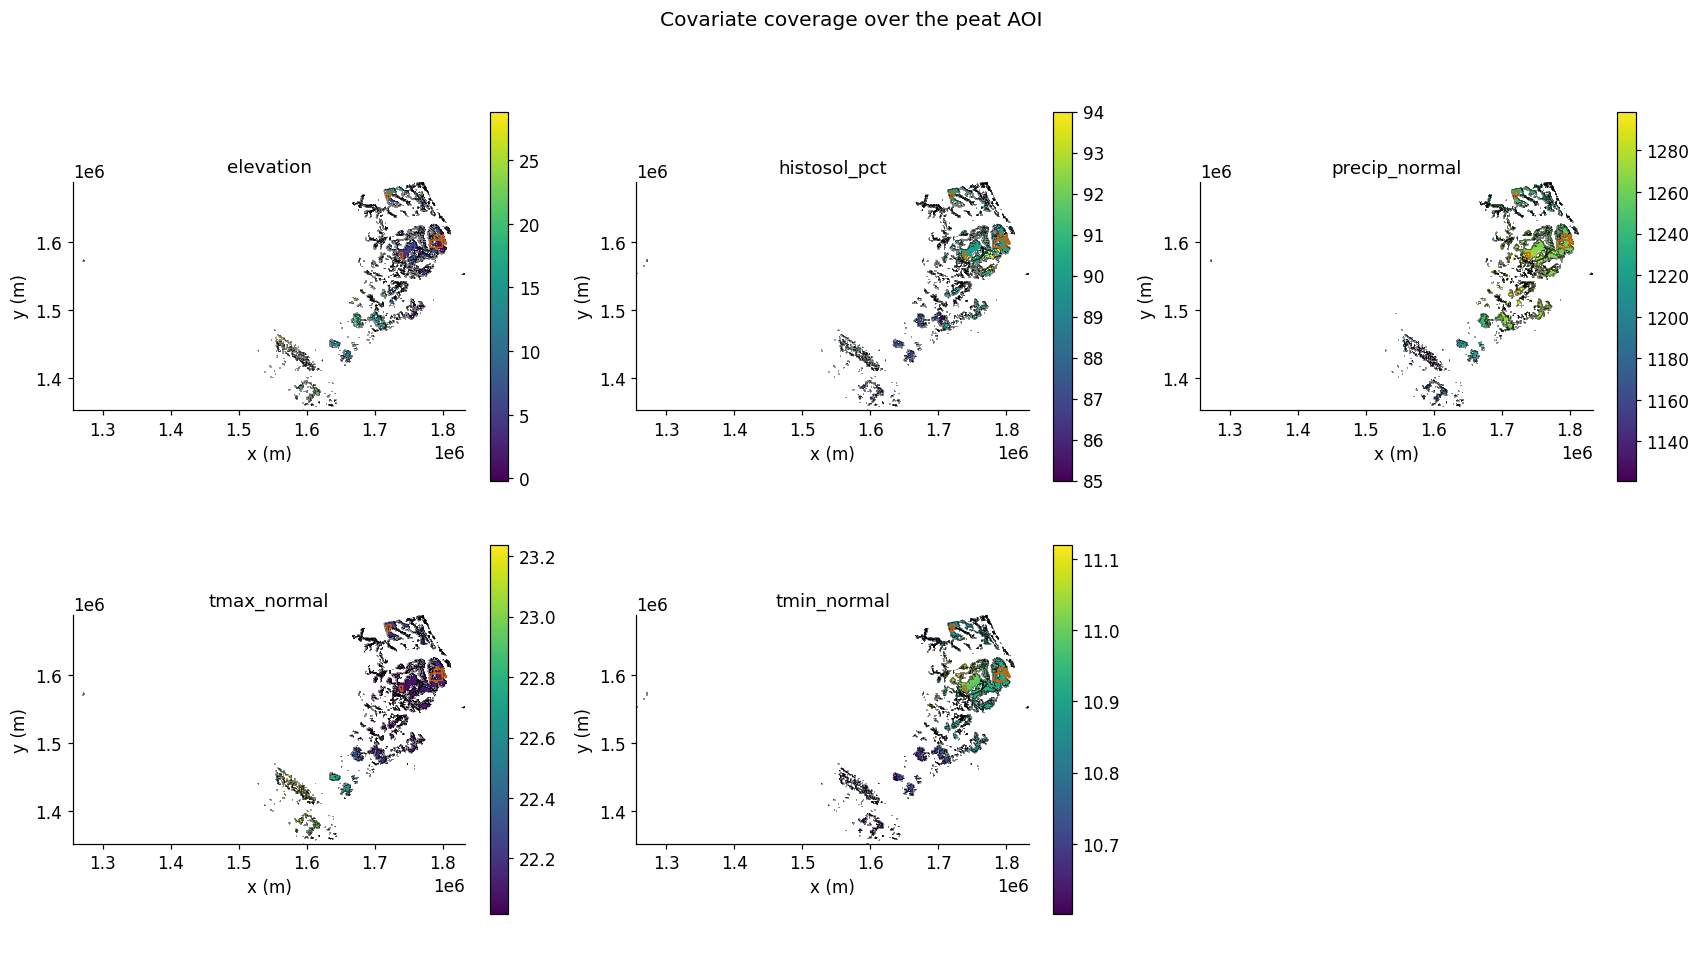

In [4]:
RES_M = 300   # analysis resolution (FireCCIS311 native ~300 m); reused below
YEARS = range(2019, 2025)   # panel / fire-product coverage; per-year climate built for these

# --- Climate from the GHCN .Rds long tables (one per element) ------------------
# load_ghcn_stations reads .Rds directly (via pyreadr): each long table carries
# one value column (PRCP / TMAX / TMIN) plus station lon/lat and a YEAR. The same
# loaded station frames feed two products:
#   * build_climate_normals -> a long-run NORMAL per pixel (STATIC): the stable
#     site climate the geographic MATCH keys off (precip_normal / tmax_normal /
#     tmin_normal in processed/climate/).
#   * build_annual_climate  -> one grid per (element, YEAR) (TEMPORAL): the
#     year-specific weather the OUTCOME / DiD stage uses (a treated:precip dry-year
#     interaction), written to processed/climate/annual/ as precip_<year>_nc.tif ...
#     and registered as the temporal covariates precip / tmax / tmin.
ghcn = data_path("interim", "climate", "ghcn")
try:
    prcp = climate.load_ghcn_stations(ghcn / "nc_prcp_long.Rds")
    tmax = climate.load_ghcn_stations(ghcn / "nc_tmax_long.Rds")
    tmin = climate.load_ghcn_stations(ghcn / "nc_tmin_long.Rds")

    # Static normals for matching (mean over the 1991-2020 baseline).
    normals = climate.build_climate_normals(
        {"precip_normal": prcp, "tmax_normal": tmax, "tmin_normal": tmin},
        aoi_nc_peat_80_histosol,
        res_m=RES_M, baseline=(1991, 2020),   # None = use every year present
    )
    written = climate.write_climate_normals(normals)
    print("wrote climate normals:", {k: p.name for k, p in written.items()})

    # Per-year weather for the outcome / DiD stage.
    annual = climate.build_annual_climate(
        {"precip": prcp, "tmax": tmax, "tmin": tmin},
        aoi_nc_peat_80_histosol,
        years=YEARS, res_m=RES_M,
    )
    written_annual = climate.write_annual_climate(annual)
    print(f"wrote {len(written_annual)} per-year climate rasters: "
          f"{sorted({e for e, _ in written_annual})} x "
          f"{sorted({y for _, y in written_annual})}")
except (FileNotFoundError, ValueError) as e:
    print("climate build skipped:", e)

# --- Soil covariates from the SSURGO GeoPackage (polygons, not a raster) -------
# Inspect the attribute columns first, then rasterise the ones you want onto the
# grid. The defaults (om_r, awc_r, drainagecl) are standard gSSURGO names; if your
# export differs, the printed columns tell you what to pass as `attributes=`.
soil_gpkg = data_path("interim", "soil", "ssurgo", "nc_soil_ssurgo.gpkg")
try:
    inspect_soil_columns(soil_gpkg)                    # <- read the columns here
    build_soil_rasters(soil_gpkg, aoi_nc_peat_80_histosol, res_m=RES_M)

except Exception as e:
    print("soil build skipped:", e)

print("covariates on disk now:", available_covariates())

# Map every covariate on disk (elevation, histosol %, climate normals, soil). A
# visually flat panel = a covariate with no spatial signal to match on.
fig = plot_covariate_maps(
    aoi_nc_peat_80_histosol,
    names=available_covariates(),
    res_m=RES_M,
    treated=peat_restoration,          # outline restoration sites for context
)
fig.savefig(FIG_DIR / "covariate_maps.png", bbox_inches="tight")
print("saved", FIG_DIR / "covariate_maps.png")

### Inspect the raw GHCN climate tables (precip, tmin, tmax)

The three `nc_*_long.Rds` files are the **raw station-day records** behind the
`precip`/`tmax`/`tmin` layers: one row per (station, day), already unit-converted
in R (precip -> mm, temps -> deg C). `load_ghcn_stations` reads them and reprojects
the station points to EPSG:5070. These are the frames the normals (1991-2020 mean)
and the per-year weather grids are both reduced from -- inspect them here before
they're collapsed.


In [5]:
# Load the three raw GHCN long tables for inspection (independent of the build
# above, so this cell stands on its own). Each is one row per station-day.
ghcn = data_path("interim", "climate", "ghcn")
raw_climate = {}
for element, fname in [("precip", "nc_prcp_long.Rds"),
                       ("tmax", "nc_tmax_long.Rds"),
                       ("tmin", "nc_tmin_long.Rds")]:
    try:
        raw_climate[element] = climate.load_ghcn_stations(ghcn / fname)
    except (FileNotFoundError, ValueError, ImportError) as e:
        print(f"{element}: could not load {fname} -- {e}")

for element, df in raw_climate.items():
    value_col = {"precip": "PRCP", "tmax": "TMAX", "tmin": "TMIN"}[element]
    n_station = df["STATION"].nunique() if "STATION" in df.columns else "?"
    if "YEAR" in df.columns:
        yr = df["YEAR"].dropna()
        year_span = f"{int(yr.min())}-{int(yr.max())}" if len(yr) else "?"
    else:
        year_span = "?"
    print(f"\n=== {element} ({value_col}) ===")
    print(f"  rows: {len(df):,}  |  stations: {n_station}  |  years: {year_span}")
    print("  columns:", list(df.columns))
    if value_col in df.columns:
        print(df[value_col].describe().to_string())

# Show one frame in full (precip if present) so you can eyeball the row structure.
_first = next(iter(raw_climate.values())) if raw_climate else None
if _first is not None:
    display(_first.head(10))



=== precip (PRCP) ===
  rows: 519,848  |  stations: 18  |  years: 1926-2026
  columns: ['STATION', 'YEAR', 'MONTH', 'DAY', 'PRCP', 'NAME', 'geometry']
count    519848.000000
mean          3.358486
std           9.844069
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        1527.800000

=== tmax (TMAX) ===
  rows: 520,553  |  stations: 18  |  years: 1926-2026
  columns: ['STATION', 'YEAR', 'MONTH', 'DAY', 'TMAX', 'NAME', 'geometry']
count    520553.000000
mean         22.351426
std           9.060730
min         -62.200000
25%          16.100000
50%          23.900000
75%          29.400000
max        1470.000000

=== tmin (TMIN) ===
  rows: 519,514  |  stations: 18  |  years: 1926-2026
  columns: ['STATION', 'YEAR', 'MONTH', 'DAY', 'TMIN', 'NAME', 'geometry']
count    519514.000000
mean          9.604885
std           9.026713
min         -51.100000
25%           2.200000
50%          10.000000
75%          17.800000
max          50.600

,STATION,YEAR,MONTH,DAY,PRCP,NAME,geometry
1,USC00312719,1926,01,1.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
2,USC00312719,1926,01,2.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
3,USC00312719,1926,01,3.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
4,USC00312719,1926,01,4.0,7.6,ELIZABETH CITY,POINT (1748537.798 1656190.608)
5,USC00312719,1926,01,5.0,6.4,ELIZABETH CITY,POINT (1748537.798 1656190.608)
6,USC00312719,1926,01,6.0,3.8,ELIZABETH CITY,POINT (1748537.798 1656190.608)
7,USC00312719,1926,01,7.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
8,USC00312719,1926,01,8.0,16.5,ELIZABETH CITY,POINT (1748537.798 1656190.608)
9,USC00312719,1926,01,9.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
10,USC00312719,1926,01,10.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)


In [6]:
inspect_soil_columns()

nc_soil_ssurgo.gpkg: 341,835 polygons, 4 polygon columns
    column   dtype  n_unique  n_null                           sample
AREASYMBOL     str        40       0     [NC013, NC015, NC017, NC019]
SPATIALVER float64        10       0           [4.0, 8.0, 14.0, 11.0]
     MUSYM     str       585       0               [StA, Le, Sb, TaB]
     MUKEY     str      1809       0 [111607, 111581, 111605, 111611]

58 layers total; soil properties are in the attribute tables:
  soil_organic_matter    column 'om_r'         -> NOT FOUND
  soil_awc               column 'awc_r'        -> NOT FOUND
  soil_drainage_class    column 'drainagecl'   -> found in 'component' (aggregated to MUKEY)


,column,dtype,n_unique,n_null,sample
0,AREASYMBOL,str,40,0,"[NC013, NC015, NC017, NC019]"
1,SPATIALVER,float64,10,0,"[4.0, 8.0, 14.0, 11.0]"
2,MUSYM,str,585,0,"[StA, Le, Sb, TaB]"
3,MUKEY,str,1809,0,"[111607, 111581, 111605, 111611]"


## 2. Build matched controls

**a. Clip-to-drop** the restoration sites (plus a buffer) from the peat frame to
get the control *candidate* pool. `how="difference"` is the inverse of clip:

```python
BUFFER_M = 1000  # exclusion halo around restoration sites, in metres
exclusion = gpd.GeoDataFrame(geometry=[restoration.buffer(BUFFER_M).union_all()],
                             crs=restoration.crs)
candidates = gpd.overlay(aoi_nc_peat_80_histosol, exclusion, how="difference")
```

**b. Candidate pixels + nearest site.** Turn candidate peat into pixel points
(e.g. centroids of the grid cells over `candidates`), then attach each one's
nearest restoration site and distance in one call:

```python
cand_pts = gpd.sjoin_nearest(candidate_points, restoration,
                             how="left", distance_col="dist_m")
```

**c. Sample covariates** at treated and candidate pixels (reuse the grid warp):
`covariate_on_grid('elevation', grid, aoi)` and `('histosol_pct', ...)`, then
read values at the pixel locations. Assemble a table with a `treatment` 0/1
column + `elevation`, `histosol_pct`.

**d. Match** treated<->control on those covariates. Two options:
- literal nearest-neighbour on z-scored covariates: `sklearn.neighbors.NearestNeighbors`
- propensity score: `pymatch.Matcher(...).fit_scores(); .match(); .matched_data`
  (matches on P(treatment), not raw covariates -- know the difference).

Output of this section: a `units` GeoDataFrame with **`treated`** (1/0),
**`site_id`** (the matched stratum), and **`unit_id`** columns. That is all
`build_frame` needs.

In [ ]:
spillover_m = 0 # set to 0 cuz TNC does a good job at preventing spillover into neighboring communities
res_m = RES_M                      # 300 m, defined in step 1b
years = range(2019, 2025)          # FireCCIS311 coverage

# Match on every CONTINUOUS covariate on disk: elevation + histosol %, plus the
# climate normals and SSURGO soil layers built/registered above. This is what
# breaks the 'match on elevation alone' degeneracy -- histosol % is ~constant on
# the 80% frame, so without climate/soil the whitened distance had only elevation
# to work with. Categorical layers (drainage class, land cover) become exact-match
# keys in match_controls, not continuous axes here.
_on_disk = set(available_covariates())
covariates = [c for c in list_covariates('continuous') if c in _on_disk]
if not covariates:                 # safety net if nothing resolved
    covariates = ['histosol_pct', 'elevation']
# Categorical soil/land-cover layers become EXACT-match keys (matched within
# class), not continuous distance axes.
categorical = [c for c in list_covariates('categorical') if c in _on_disk]
print('matching on continuous covariates:', covariates)
print('exact-match (categorical) keys:', categorical)

# Pixel-YEAR panel (not a single flattened set): every candidate pixel is
# repeated once per calendar year, with
#   - `treated`                  1 once the pixel's site has been restored, else 0
#   - `<restoration_yr_col>`      the site's End_Yr (NaN for control-pool pixels)
#   - `years_after_restoration`  = year - End_Yr  (0 = restoration year,
#                                  matching the notebook's event_year convention)
# Control pixels appear in every year with treated=0. Pre-restoration site
# pixels are kept as *not-yet-treated* controls for the staggered DiD below
# (pass drop_pretreatment=True for the simpler restored-by-year-Y cross-section).
pixels = get_treated_and_control_pixels(
    aoi_nc_peat_80_histosol,
    peat_restoration,
    years=years,
    spillover_m=spillover_m,
    res_m=res_m,
    treated_col_name="treated",
    restoration_yr_col=restoration_yr_col,   # 'End_Yr', kept under this name
    site_col="Proj_Name",
)

# Static covariates are sampled once per pixel and broadcast across the years.
pixels_with_covariates = attach_covariates(pixels, covariates, aoi_nc_peat_80_histosol, res_m)

print(pixels_with_covariates.shape)
print("treated pixel-years by calendar year:")
print(pixels_with_covariates.groupby("year")["treated"].sum())
pixels_with_covariates.head()

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_organic_matter: no file matches ssurgo_organic_matter*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_awc: no file matches ssurgo_awc*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil

matching on continuous covariates: ['elevation', 'histosol_pct', 'precip_normal', 'tmax_normal', 'tmin_normal']
exact-match (categorical) keys: []
(338088, 16)
treated pixel-years by calendar year:
year
2019    3428
2020    3428
2021    3791
2022    3791
2023    4335
2024    4335
Name: treated, dtype: int64


,x,y,geometry,End_Yr,Proj_Name,year,years_after_restoration,treated,elevation,histosol_pct,precip_normal,tmax_normal,tmin_normal,precip,tmax,tmin
0,1.795060e+06,1.600476e+06,POINT (1795060.262 1600475.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,1.469855,90.0,1257.338745,22.141127,10.911558,1251.931274,22.614788,11.705546
1,1.792360e+06,1.598976e+06,POINT (1792360.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,3.633824,90.0,1257.894897,22.138178,10.915177,1249.973267,22.610678,11.711951
2,1.792660e+06,1.598976e+06,POINT (1792660.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,4.391799,90.0,1257.868286,22.138357,10.914702,1250.011230,22.610662,11.710670
3,1.792960e+06,1.598976e+06,POINT (1792960.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,3.524289,90.0,1257.841919,22.138535,10.914229,1250.047607,22.610649,11.709395
4,1.793260e+06,1.598976e+06,POINT (1793260.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,2.983579,90.0,1257.815796,22.138710,10.913760,1250.082642,22.610634,11.708131


### Inspect treated vs control in covariate space

Before matching, look at the two groups in covariate space. A **flat axis** is a
covariate with no spread (nothing to match on there); with climate + soil added,
treated and control should now separate on more than just elevation. The scatter
matrix shows every covariate axis at once.

saved covariate-space diagnostics -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


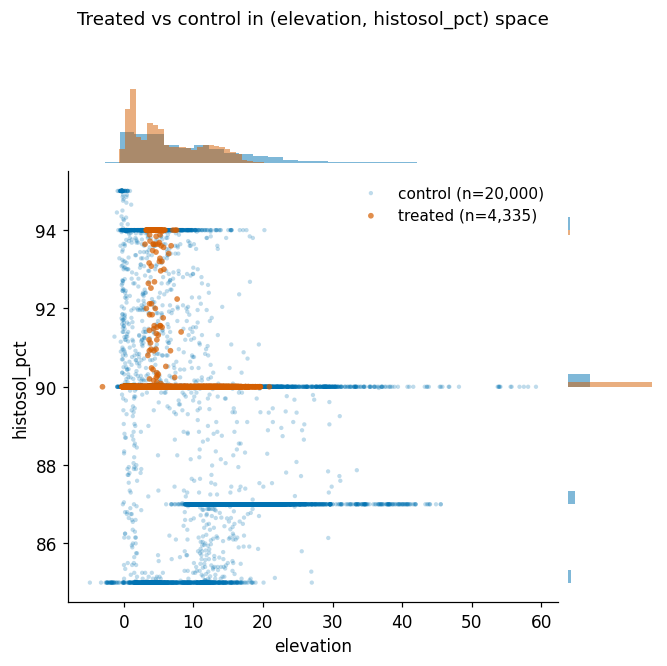

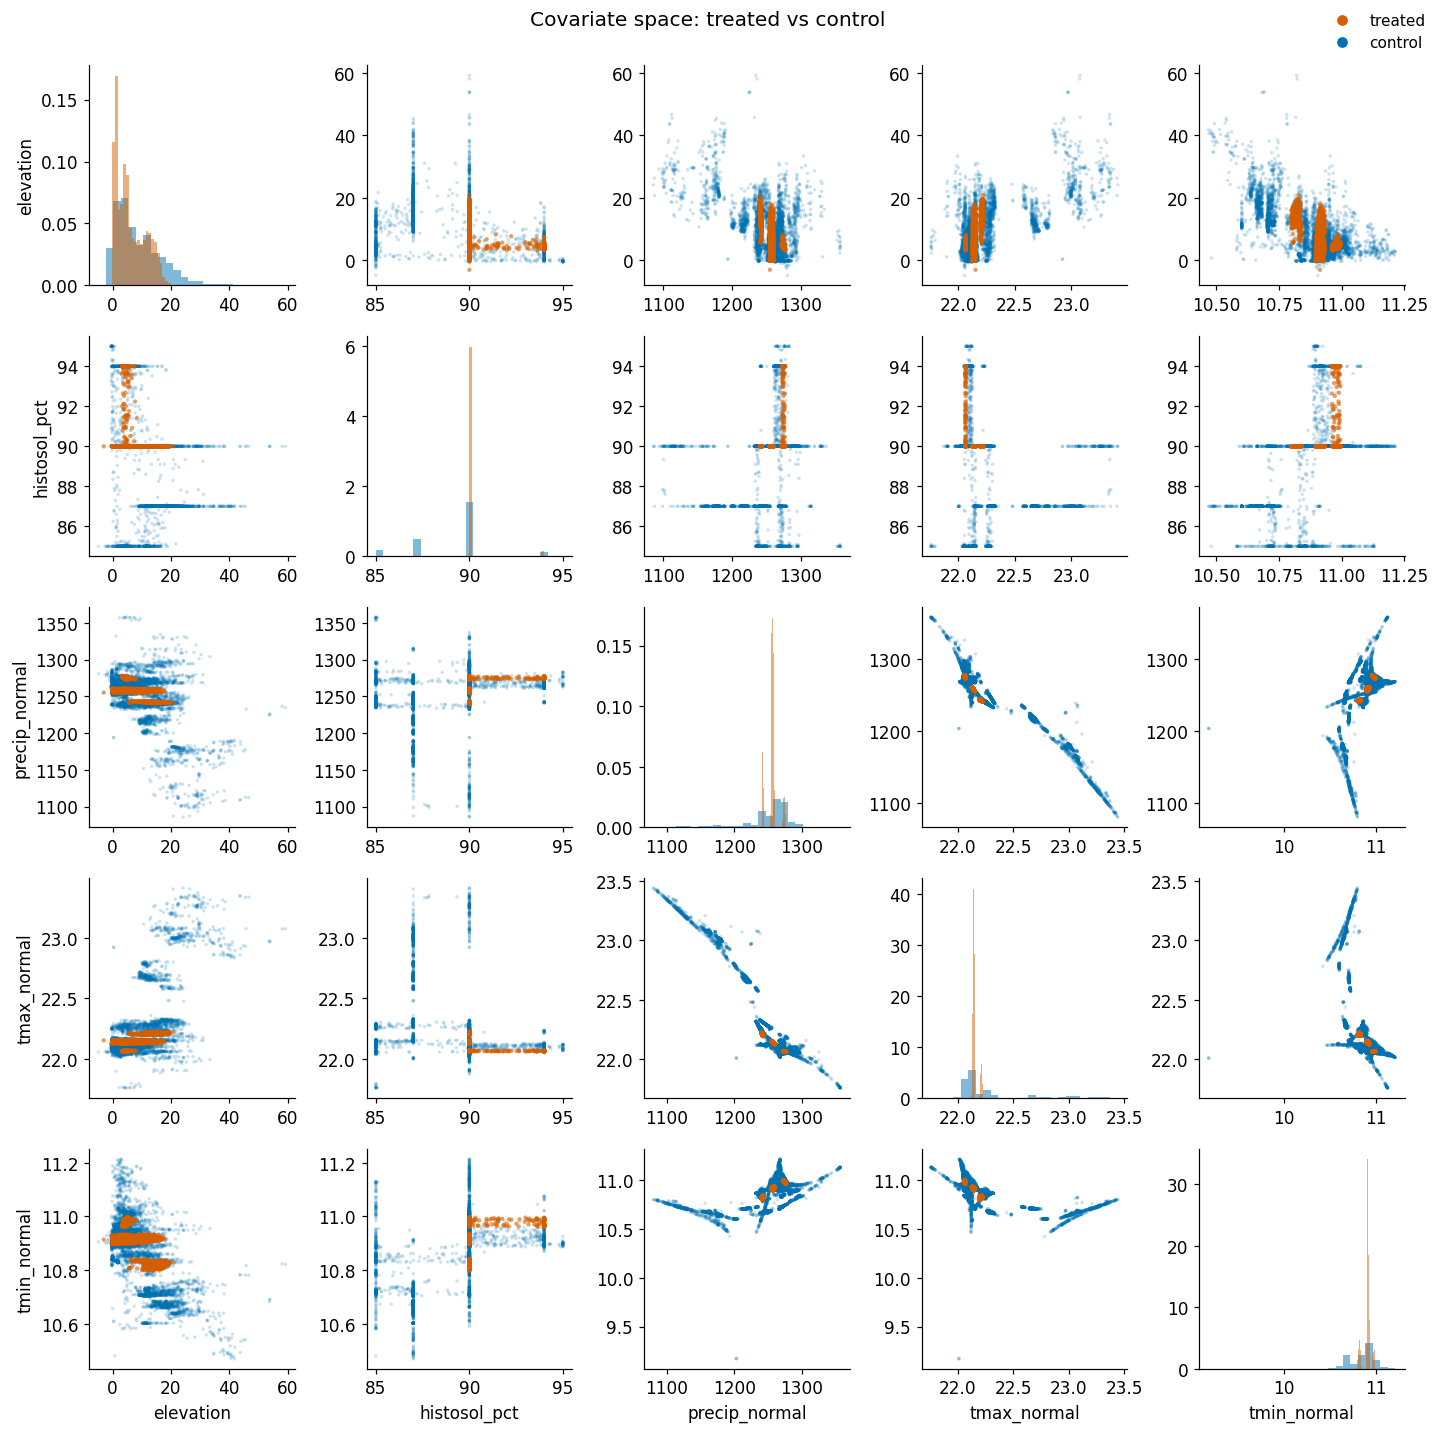

In [8]:
fig = plot_covariate_space(
    pixels_with_covariates, "elevation", "histosol_pct",
    restoration_yr_col=restoration_yr_col,
)
fig.savefig(FIG_DIR / "covariate_space_elev_histosol.png", bbox_inches="tight")

if len(covariates) >= 2:
    fig = plot_covariate_pairs(
        pixels_with_covariates, covariates, restoration_yr_col=restoration_yr_col,
    )
    fig.savefig(FIG_DIR / "covariate_pairs.png", bbox_inches="tight")
print("saved covariate-space diagnostics ->", FIG_DIR)

## 2b. Event-time panel → staggered DiD

The pixel-year panel above already carries what the staggered
difference-in-differences in `peatfire.modeling.did` needs: a per-pixel
`treated` that switches on at each site's `restoration_year`, and that
restoration year itself (the Callaway–Sant'Anna **cohort** `g`). Below we
attach the fire response per year, give every pixel a stable `unit_id`, thread
`restoration_year` into `did.attach_cohort`, and fit the group-time ATT.

This is the design that identifies off the *change* in burning after each
site's restoration relative to not-yet/never-restored controls, so every
time-invariant confounder differences out. The `build_frame` →
`fit_logit_clustered` route in §3–4 is the **levels / odds-ratio** alternative,
which consumes matched `units` polygons from Stage 5–7 rather than this panel.

In [9]:
# --- 1. fire response per (pixel, year), sampled from the swappable product ---
# Mirrors build_frame's per-year response step, but samples at pixel points
# instead of rasterizing polygons. Needs the fire product on disk.
product = "FireCCIS311"
grid = build_common_grid(aoi_nc_peat_80_histosol, res_m=res_m)

panel = pixels_with_covariates.copy()
panel["burned"] = np.nan
for year, idx in panel.groupby("year").groups.items():
    resp = load_standardized(product, int(year), aoi_nc_peat_80_histosol)
    if resp is None:                       # product missing this year -> leave NaN
        continue
    burned = to_common_grid(resp.astype("float32"), grid, how="max")
    sub = panel.loc[idx]
    xi = xr.DataArray(sub["x"].values, dims="point")
    yi = xr.DataArray(sub["y"].values, dims="point")
    panel.loc[idx, "burned"] = burned.sel(x=xi, y=yi, method="nearest").values

# --- 2. one stable entity id per distinct pixel (the DiD panel's entity) ---
panel["unit_id"] = panel.groupby(["x", "y"]).ngroup()

# --- 3. thread the restoration year -> CS cohort `g` (0 = never-treated controls) ---
# cohort_by maps each site to its first-treatment (restoration) year; control-pool
# pixels have no Proj_Name and fall through to g=0 (never-treated).
cohort_by = (
    panel.dropna(subset=[restoration_yr_col])
    .groupby("Proj_Name")[restoration_yr_col]
    .first()
)
panel = did.attach_cohort(panel, cohort_by=cohort_by, key="Proj_Name", treated_col="treated")

print("cohorts g:", sorted(panel["g"].unique()))
print("burned pixel-years with coverage:", int(panel["burned"].notna().sum()))
panel.head()

cohorts g: [np.int64(0), np.int64(2019), np.int64(2021), np.int64(2023)]
burned pixel-years with coverage: 338082


,x,y,geometry,End_Yr,Proj_Name,year,years_after_restoration,treated,elevation,histosol_pct,precip_normal,tmax_normal,tmin_normal,precip,tmax,tmin,burned,unit_id,g
0,1.795060e+06,1.600476e+06,POINT (1795060.262 1600475.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,1.469855,90.0,1257.338745,22.141127,10.911558,1251.931274,22.614788,11.705546,0.0,53533,2019
1,1.792360e+06,1.598976e+06,POINT (1792360.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,3.633824,90.0,1257.894897,22.138178,10.915177,1249.973267,22.610678,11.711951,0.0,52560,2019
2,1.792660e+06,1.598976e+06,POINT (1792660.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,4.391799,90.0,1257.868286,22.138357,10.914702,1250.011230,22.610662,11.710670,0.0,52664,2019
3,1.792960e+06,1.598976e+06,POINT (1792960.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,3.524289,90.0,1257.841919,22.138535,10.914229,1250.047607,22.610649,11.709395,0.0,52766,2019
4,1.793260e+06,1.598976e+06,POINT (1793260.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,2.983579,90.0,1257.815796,22.138710,10.913760,1250.082642,22.610634,11.708131,0.0,52876,2019


In [10]:
# Reshape to the balanced (unit, year) panel and fit the doubly-robust
# group-time ATT (Callaway & Sant'Anna 2021). Needs `pip install differences`
# and a `burned` column with coverage, so we drop the year-loop's NaNs first.
# Wrapped so a missing optional backend / fire coverage doesn't abort the rest
# of the notebook (the levels / odds-ratio route in §3-4 is self-contained).
_cont = set(list_covariates('continuous'))
covs = [c for c in panel.columns if c in _cont]

event_study = None
try:
    cs_panel = did.build_panel(
        panel.dropna(subset=["burned"]),
        entity="unit_id",
        time="year",
        response="burned",
        covariates=covs,
    )

    att = did.estimate_att(cs_panel, response="burned", covariates=covs, cluster="unit_id")

    overall = did.aggregate_att(att, kind="simple")   # Castro's headline ATT
    event_study = did.aggregate_att(att, kind="event")  # pre-trends check + dynamics
    print("overall ATT:", overall)

    # Save the event-study path (pre-treatment points are the parallel-trends check).
    try:
        ax = att.plot("event")
        fig = ax.get_figure() if hasattr(ax, "get_figure") else plt.gcf()
        fig.savefig(FIG_DIR / "did_event_study.png", bbox_inches="tight")
        print("saved", FIG_DIR / "did_event_study.png")
    except Exception as e:  # backend plotter API differs / not available
        print("event-study plot skipped:", e)
except Exception as e:
    print("staggered DiD skipped (needs `differences` backend + fire coverage):", e)

event_study

staggered DiD skipped (needs `differences` backend + fire coverage): No module named 'differences'


### Event study: burning vs time since restoration

`plot_event_study` renders the temporal picture the covariate diagnostics can't:
the staggered-DiD ATT by **event time** (years since each site's restoration),
straight from `did.aggregate_att(att, kind="event")`. Event time 0 is the
restoration year; the **pre-treatment points (shaded, left of the onset line) are
the parallel-trends check** -- they should straddle zero, i.e. treated and control
were on the same burning trajectory *before* the canal blocks went in -- and the
post-treatment points trace how the restoration effect on burning evolves after.


In [11]:
# Temporal diagnostic for the DiD: ATT vs time since restoration, with the
# pre-period points as the parallel-trends check. Consumes the `event_study`
# frame from aggregate_att(..., kind="event") above; skipped if the DiD didn't run.
if event_study is not None:
    fig = plot_event_study(event_study, ylabel="ATT on P(burn)")
    fig.savefig(FIG_DIR / "did_event_study_tidy.png", bbox_inches="tight")
    print("saved", FIG_DIR / "did_event_study_tidy.png")
    display(fig)
else:
    print("event study skipped (no DiD result to plot -- see the cell above).")


event study skipped (no DiD result to plot -- see the cell above).


### Raw burned rate: the unadjusted signal

Before any matching or DiD adjustment, the plainest look at the outcome — the
observed burn rate for treated (restoration) vs control pixels.
`plot_raw_burn_rate_by_year` splits it by **calendar year** (the shared dry /
El Niño swings show up in both groups); `plot_raw_burn_rate_by_event_time`
re-aligns it to **years since each site's restoration** (event time 0 = the
restoration year) — the model-free companion to the DiD event study above. On
the pixel panel the control pool has no restoration year, so it is drawn as a
flat pooled-mean reference; on a matched set (where each control inherits its
site's cohort) both groups get an aligned event-time curve.

In [ ]:
# Raw, unadjusted burn rate straight off the pixel-year `panel` (from §2b) — the
# descriptive signal the DiD / logit are built to explain, before any adjustment.
fig = plot_raw_burn_rate_by_year(panel, restoration_yr_col=restoration_yr_col)
fig.savefig(FIG_DIR / "raw_burn_rate_by_year.png", bbox_inches="tight")
display(fig)

fig = plot_raw_burn_rate_by_event_time(panel, restoration_yr_col=restoration_yr_col)
fig.savefig(FIG_DIR / "raw_burn_rate_by_event_time.png", bbox_inches="tight")
display(fig)
print("saved raw_burn_rate_by_year.png, raw_burn_rate_by_event_time.png ->", FIG_DIR)

In [12]:
# --- 1. fire response per (pixel, year), sampled from the swappable product ---
# Mirrors build_frame's per-year response step, but samples at pixel points
# instead of rasterizing polygons. Needs the fire product on disk.
product = "FireCCIS311"
grid = build_common_grid(aoi_nc_peat_80_histosol, res_m=res_m)

panel = pixels_with_covariates.copy()
panel["burned"] = np.nan
for year, idx in panel.groupby("year").groups.items():
    resp = load_standardized(product, int(year), aoi_nc_peat_80_histosol)
    if resp is None:                       # product missing this year -> leave NaN
        continue
    burned = to_common_grid(resp.astype("float32"), grid, how="max")
    sub = panel.loc[idx]
    xi = xr.DataArray(sub["x"].values, dims="point")
    yi = xr.DataArray(sub["y"].values, dims="point")
    panel.loc[idx, "burned"] = burned.sel(x=xi, y=yi, method="nearest").values

# --- 2. one stable entity id per distinct pixel (the DiD panel's entity) ---
panel["unit_id"] = panel.groupby(["x", "y"]).ngroup()

# --- 3. thread the restoration year -> CS cohort `g` (0 = never-treated controls) ---
# cohort_by maps each site to its first-treatment (restoration) year; control-pool
# pixels have no Proj_Name and fall through to g=0 (never-treated).
cohort_by = (
    panel.dropna(subset=[restoration_yr_col])
    .groupby("Proj_Name")[restoration_yr_col]
    .first()
)
panel = did.attach_cohort(panel, cohort_by=cohort_by, key="Proj_Name", treated_col="treated")

print("cohorts g:", sorted(panel["g"].unique()))
print("burned pixel-years with coverage:", int(panel["burned"].notna().sum()))
panel.head()

cohorts g: [np.int64(0), np.int64(2019), np.int64(2021), np.int64(2023)]
burned pixel-years with coverage: 338082


,x,y,geometry,End_Yr,Proj_Name,year,years_after_restoration,treated,elevation,histosol_pct,precip_normal,tmax_normal,tmin_normal,precip,tmax,tmin,burned,unit_id,g
0,1.795060e+06,1.600476e+06,POINT (1795060.262 1600475.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,1.469855,90.0,1257.338745,22.141127,10.911558,1251.931274,22.614788,11.705546,0.0,53533,2019
1,1.792360e+06,1.598976e+06,POINT (1792360.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,3.633824,90.0,1257.894897,22.138178,10.915177,1249.973267,22.610678,11.711951,0.0,52560,2019
2,1.792660e+06,1.598976e+06,POINT (1792660.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,4.391799,90.0,1257.868286,22.138357,10.914702,1250.011230,22.610662,11.710670,0.0,52664,2019
3,1.792960e+06,1.598976e+06,POINT (1792960.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,3.524289,90.0,1257.841919,22.138535,10.914229,1250.047607,22.610649,11.709395,0.0,52766,2019
4,1.793260e+06,1.598976e+06,POINT (1793260.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,2.983579,90.0,1257.815796,22.138710,10.913760,1250.082642,22.610634,11.708131,0.0,52876,2019


In [13]:
# Reshape to the balanced (unit, year) panel and fit the doubly-robust
# group-time ATT (Callaway & Sant'Anna 2021). Needs `pip install differences`
# and a `burned` column with coverage, so we drop the year-loop's NaNs first.
# Wrapped so a missing optional backend / fire coverage doesn't abort the rest
# of the notebook (the levels / odds-ratio route in §3-4 is self-contained).
covs = [c for c in ("elevation", "histosol_pct") if c in panel.columns]

event_study = None
try:
    cs_panel = did.build_panel(
        panel.dropna(subset=["burned"]),
        entity="unit_id",
        time="year",
        response="burned",
        covariates=covs,
    )

    att = did.estimate_att(cs_panel, response="burned", covariates=covs, cluster="unit_id")

    overall = did.aggregate_att(att, kind="simple")   # Castro's headline ATT
    event_study = did.aggregate_att(att, kind="event")  # pre-trends check + dynamics
    print("overall ATT:", overall)

    # Save the event-study path (pre-treatment points are the parallel-trends check).
    try:
        ax = att.plot("event")
        fig = ax.get_figure() if hasattr(ax, "get_figure") else plt.gcf()
        fig.savefig(FIG_DIR / "did_event_study.png", bbox_inches="tight")
        print("saved", FIG_DIR / "did_event_study.png")
    except Exception as e:  # backend plotter API differs / not available
        print("event-study plot skipped:", e)
except Exception as e:
    print("staggered DiD skipped (needs `differences` backend + fire coverage):", e)

event_study

staggered DiD skipped (needs `differences` backend + fire coverage): No module named 'differences'


### Match controls + balance (Stage 5-7) → `units`

This is the causal-design heart: pair every treated (restoration) pixel with the
nearest control pixel on the covariates, then *prove it worked*.

1. **`match_controls`** — whiten the covariates (so plain Euclidean distance =
   Mahalanobis) and nearest-neighbour match each treated pixel to a control
   within a caliper. Exact-match categoricals (land cover) once they download.
2. **`balance_table` + `plot_balance`** — the standardized mean difference (SMD)
   per covariate, *before* vs *after* matching. Before, the groups are offset;
   after, `|SMD|` should collapse below 0.1. That overlap is what later lets us
   attribute a fire difference to restoration rather than to geography. The love
   plot is saved to `outputs/figures/modeling/balance_love.png`.
3. **`assemble_units`** — shape the matched pixels into the `units` GeoDataFrame
   (`unit_id`, `site_id`, `treated`, `geometry`) that `build_frame` consumes in §3.

[match] 3550 treated matched to 3550 controls (k=1, caliper=1.0, replace=False); dropped 0 treated pixels with no control in caliper
[Stage 5 OK] 3,550 treated matched to 3,550 controls; max distance 0.587 <= caliper 1.
[Stage 6 OK] balance improved; post-match max |SMD| = 0.072.
               smd_before  smd_after
elevation       -0.412614   0.023497
histosol_pct     0.592022   0.004544
precip_normal    0.241623   0.033179
tmax_normal     -0.510738  -0.072497
tmin_normal      0.504839  -0.023768
site clusters (effective N): 5
saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/balance_love.png
units by treatment:
 treated
1    3550
0    3550
Name: count, dtype: int64


,unit_id,site_id,treated,geometry,x,y,elevation,histosol_pct,precip_normal,tmax_normal,tmin_normal,End_Yr,pair_id,match_distance
0,0,Dare Bombing Range WMP,1,POINT (1795060.262 1600475.871),1.795060e+06,1.600476e+06,1.469855,90.0,1257.338745,22.141127,10.911558,2019.0,0,0.000000
1,1,Dare Bombing Range WMP,0,POINT (1797760.262 1610375.871),1.797760e+06,1.610376e+06,1.464512,90.0,1254.979370,22.152781,10.909152,NaN,0,0.116329
2,2,Dare Bombing Range WMP,1,POINT (1792360.262 1598975.871),1.792360e+06,1.598976e+06,3.633824,90.0,1257.894897,22.138178,10.915177,2019.0,1,0.000000
3,3,Dare Bombing Range WMP,0,POINT (1788160.262 1589975.871),1.788160e+06,1.589976e+06,3.741378,90.0,1260.331543,22.127703,10.916336,NaN,1,0.135097
4,4,Dare Bombing Range WMP,1,POINT (1792660.262 1598975.871),1.792660e+06,1.598976e+06,4.391799,90.0,1257.868286,22.138357,10.914702,2019.0,2,0.000000


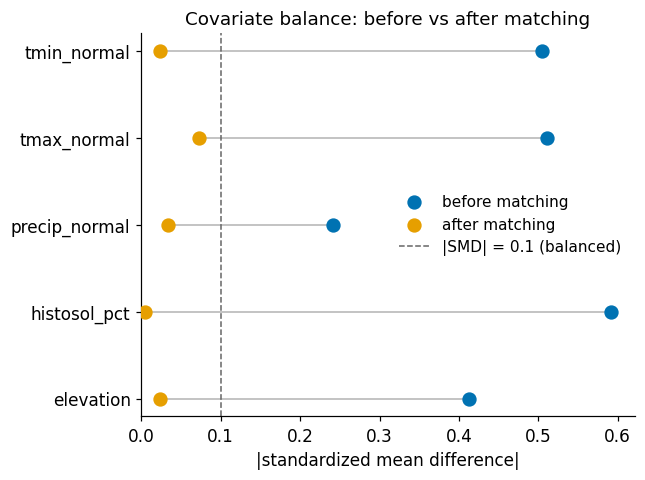

In [14]:
caliper = 1.0   # max match distance, in whitened (Mahalanobis SD) units
k = 1           # 1:1 matching

# --- Stage 6a: balance BEFORE matching -------------------------------------
# On the unmatched panel, balance_table collapses to unique pixels and splits by
# restoration-site membership (treated) vs the candidate pool (control).
before = balance_table(pixels_with_covariates, continuous=covariates,
                       restoration_yr_col=restoration_yr_col)

# --- Stage 5: nearest-neighbour match on the (whitened) covariates ---------
# No categorical layer on disk yet; add categorical=['land_cover'] to exact-match
# once it downloads. replace=False -> each control used at most once. site_id in
# the output is the restoration SITE (Proj_Name): a control inherits its matched
# treated pixel's site, so SEs later cluster on the handful of sites, not pixels.
matched = match_controls(
    pixels_with_covariates,
    continuous=covariates,
    categorical=(),
    caliper=caliper,
    k=k,
    replace=False,
    restoration_yr_col=restoration_yr_col,   # 'End_Yr'
    site_col="Proj_Name",
)

# --- Stage 6b: balance AFTER matching + the checks -------------------------
after = balance_table(matched, continuous=covariates)
check_matches(matched, caliper=caliper)   # every control within the caliper
check_balance(before, after)              # |SMD| shrank for every covariate

balance = before.join(after, lsuffix="_before", rsuffix="_after")
print(balance)
print("site clusters (effective N):", matched["site_id"].nunique())

# --- Stage 6c: the love plot (the figure that justifies the design) --------
ax = plot_balance(before, after)
ax.get_figure().savefig(FIG_DIR / "balance_love.png", bbox_inches="tight")
print("saved", FIG_DIR / "balance_love.png")

# --- Stage 7: package the matched pixels into `units` for build_frame ------
units = assemble_units(matched)
print("units by treatment:\n", units["treated"].value_counts())
units.head()

In [31]:
# save units as gdf so we can inspect it in the fire comparison notebook
controls = units[units["treated"] == 0].copy()

out = data_path("processed", "peat_restoration", "matched_controls", "matched_controls.gpkg")
out.parent.mkdir(parents=True, exist_ok=True)
controls.to_file(out, driver="GPKG")
print("saved", len(controls), "control sites ->", out)

saved 3550 control sites -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/peat_restoration/matched_controls/matched_controls.gpkg


## 3. Build the tidy pixel-year frame

In [15]:
# Consumes the matched `units` from Stage 7. Response is swappable via `product=`.
# site_id_col='site_id' -> the restoration SITE assemble_units carries through;
# that is what fit_logit_clustered clusters the standard errors on (effective N =
# number of restoration sites, not pixels).
frame = build_frame(
    units,
    product="FireCCIS311",   # swap for a severity product to model severity
    years=range(2019, 2025),
    covariate_names=None,    # default = every covariate on disk (elev, histosol)
    site_id_col='site_id',
)
print(frame.shape)
print("burn rate by treatment:")
print(frame.groupby("treated")["burned"].mean())
frame.head()

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_organic_matter: no file matches ssurgo_organic_matter*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_awc: no file matches ssurgo_awc*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil

(42576, 15)
burn rate by treatment:
treated
0.0    0.006204
1.0    0.034554
Name: burned, dtype: float32


,unit_id,site_id,treated,y,x,elevation,histosol_pct,precip_normal,tmax_normal,tmin_normal,year,burned,precip,tmax,tmin
0,6807.0,3.0,0.0,1.680126e+06,1.734310e+06,10.707357,90.000000,1238.856079,22.242447,10.823696,2019,0.0,1354.809326,22.780247,11.730297
1,6897.0,3.0,0.0,1.679826e+06,1.734610e+06,14.809400,90.000000,1238.766846,22.243761,10.825116,2019,0.0,1356.104736,22.781425,11.730947
2,6413.0,3.0,0.0,1.679226e+06,1.727410e+06,14.631072,90.000000,1240.051147,22.225906,10.811803,2019,0.0,1339.208252,22.767065,11.731242
3,6503.0,3.0,0.0,1.678926e+06,1.725910e+06,15.694160,90.080002,1240.323364,22.221983,10.808803,2019,0.0,1335.479248,22.763933,11.731246
4,7093.0,3.0,0.0,1.678926e+06,1.726210e+06,16.738960,90.000000,1240.267212,22.222847,10.809619,2019,0.0,1336.318604,22.764652,11.731464


### Match controls + balance (Stage 5-7) → `units`

This is the causal-design heart: pair every treated (restoration) pixel with the
nearest control pixel on the covariates, then *prove it worked*.

1. **`match_controls`** — whiten the covariates (so plain Euclidean distance =
   Mahalanobis) and nearest-neighbour match each treated pixel to a control
   within a caliper. Exact-match categoricals (land cover) once they download.
2. **`balance_table` + `plot_balance`** — the standardized mean difference (SMD)
   per covariate, *before* vs *after* matching. Before, the groups are offset;
   after, `|SMD|` should collapse below 0.1. That overlap is what later lets us
   attribute a fire difference to restoration rather than to geography. The love
   plot is saved to `outputs/figures/modeling/balance_love.png`.
3. **`assemble_units`** — shape the matched pixels into the `units` GeoDataFrame
   (`unit_id`, `site_id`, `treated`, `geometry`) that `build_frame` consumes in §3.

[match] 3550 treated matched to 3550 controls (k=1, caliper=1.0, replace=False); dropped 0 treated pixels with no control in caliper
[Stage 5 OK] 3,550 treated matched to 3,550 controls; max distance 0.587 <= caliper 1.
[Stage 6 OK] balance improved; post-match max |SMD| = 0.072.
               smd_before  smd_after
elevation       -0.412614   0.023497
histosol_pct     0.592022   0.004544
precip_normal    0.241623   0.033179
tmax_normal     -0.510738  -0.072497
tmin_normal      0.504839  -0.023768
site clusters (effective N): 5
saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/balance_love.png
units by treatment:
 treated
1    3550
0    3550
Name: count, dtype: int64


,unit_id,site_id,treated,geometry,x,y,elevation,histosol_pct,precip_normal,tmax_normal,tmin_normal,End_Yr,pair_id,match_distance
0,0,Dare Bombing Range WMP,1,POINT (1795060.262 1600475.871),1.795060e+06,1.600476e+06,1.469855,90.0,1257.338745,22.141127,10.911558,2019.0,0,0.000000
1,1,Dare Bombing Range WMP,0,POINT (1797760.262 1610375.871),1.797760e+06,1.610376e+06,1.464512,90.0,1254.979370,22.152781,10.909152,NaN,0,0.116329
2,2,Dare Bombing Range WMP,1,POINT (1792360.262 1598975.871),1.792360e+06,1.598976e+06,3.633824,90.0,1257.894897,22.138178,10.915177,2019.0,1,0.000000
3,3,Dare Bombing Range WMP,0,POINT (1788160.262 1589975.871),1.788160e+06,1.589976e+06,3.741378,90.0,1260.331543,22.127703,10.916336,NaN,1,0.135097
4,4,Dare Bombing Range WMP,1,POINT (1792660.262 1598975.871),1.792660e+06,1.598976e+06,4.391799,90.0,1257.868286,22.138357,10.914702,2019.0,2,0.000000


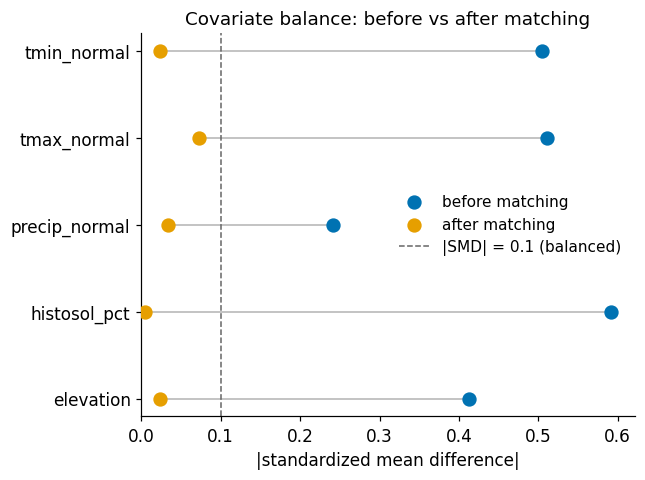

In [16]:
caliper = 1.0   # max match distance, in whitened (Mahalanobis SD) units
k = 1           # 1:1 matching

# --- Stage 6a: balance BEFORE matching -------------------------------------
# On the unmatched panel, balance_table collapses to unique pixels and splits by
# restoration-site membership (treated) vs the candidate pool (control).
before = balance_table(pixels_with_covariates, continuous=covariates,
                       restoration_yr_col=restoration_yr_col)

# --- Stage 5: nearest-neighbour match on the (whitened) covariates ---------
# No categorical layer on disk yet; add categorical=['land_cover'] to exact-match
# once it downloads. replace=False -> each control used at most once. site_id in
# the output is the restoration SITE (Proj_Name): a control inherits its matched
# treated pixel's site, so SEs later cluster on the handful of sites, not pixels.
matched = match_controls(
    pixels_with_covariates,
    continuous=covariates,
    categorical=categorical,   # exact-match within land-cover / drainage class
    caliper=caliper,
    k=k,
    replace=False,
    restoration_yr_col=restoration_yr_col,   # 'End_Yr'
    site_col="Proj_Name",
)

# --- Stage 6b: balance AFTER matching + the checks -------------------------
after = balance_table(matched, continuous=covariates)
check_matches(matched, caliper=caliper)   # every control within the caliper
check_balance(before, after)              # |SMD| shrank for every covariate

balance = before.join(after, lsuffix="_before", rsuffix="_after")
print(balance)
print("site clusters (effective N):", matched["site_id"].nunique())

# --- Stage 6c: the love plot (the figure that justifies the design) --------
ax = plot_balance(before, after)
ax.get_figure().savefig(FIG_DIR / "balance_love.png", bbox_inches="tight")
print("saved", FIG_DIR / "balance_love.png")

# --- Stage 7: package the matched pixels into `units` for build_frame ------
units = assemble_units(matched)
print("units by treatment:\n", units["treated"].value_counts())
units.head()

### Inspect the matches themselves

Per-pair companion to the love plot. In **covariate space**, short segments =
close covariate twins. In the **geographic** view, long connecting lines flag
controls drawn far from their treated site -- possible spatial confounding
(distant controls may differ in unmeasured ways), the reason for adding
climate/soil and, if needed, an exact-match key.

saved matched-pair diagnostics -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


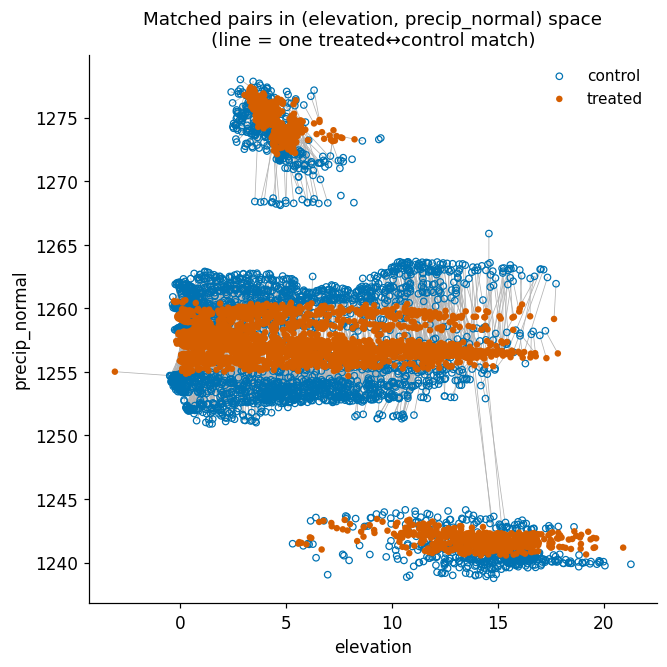

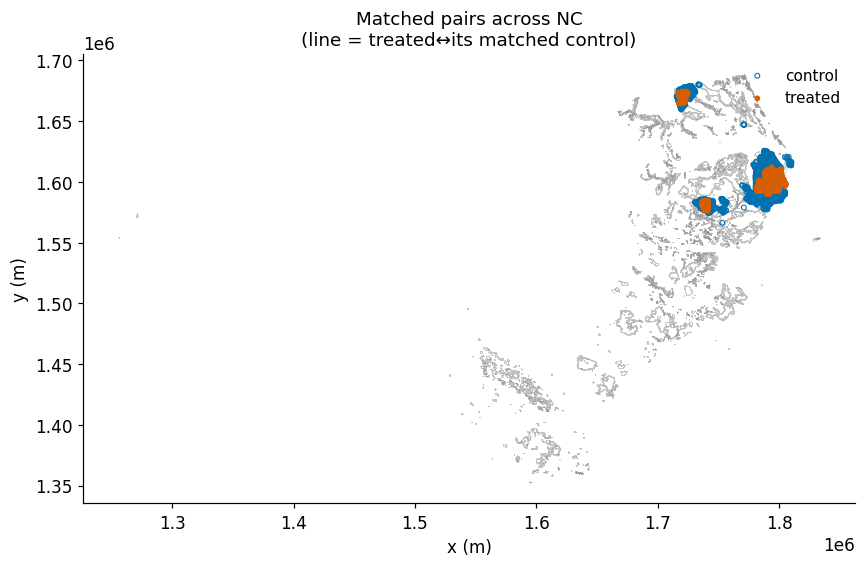

In [17]:
# Prefer two axes with real spread (elevation + a climate/soil covariate) over
# the ~constant histosol for the covariate-space view.
_axes = [c for c in covariates if c != "histosol_pct"] or list(covariates)
_xc = _axes[0]
_yc = _axes[1] if len(_axes) > 1 else "histosol_pct"

fig = plot_matched_pairs_covariate(matched, _xc, _yc)
fig.savefig(FIG_DIR / "matched_pairs_covariate.png", bbox_inches="tight")

fig = plot_matched_pairs_geographic(matched, aoi=aoi_nc_peat_80_histosol)
fig.savefig(FIG_DIR / "matched_pairs_geographic.png", bbox_inches="tight")
print("saved matched-pair diagnostics ->", FIG_DIR)

saved candidate/control pixel map -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


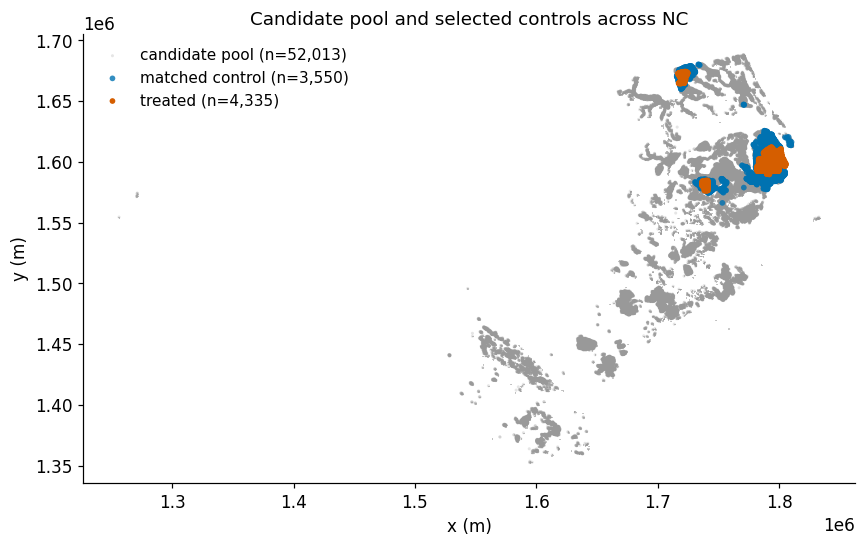

In [18]:
# Candidate pool vs the controls the match actually selected, over NC. The grey
# backdrop is the full control candidate pool (every peat pixel outside the
# treated + spillover halo); the blue points are the subset chosen as matched
# controls, and orange the treated restoration pixels. Tells you whether the
# match drew controls from across the frame or clustered them near the sites.
fig = plot_candidate_control_pixels(
    pixels_with_covariates, matched=matched, aoi=aoi_nc_peat_80_histosol,
    restoration_yr_col=restoration_yr_col,
)
fig.savefig(FIG_DIR / "candidate_control_pixels.png", bbox_inches="tight")
print("saved candidate/control pixel map ->", FIG_DIR)

## 2c. Faithful Castro (2026) matching: per-year prognostic + per-vintage propensity + event-time trajectory

The match in §2 pairs pixels on a single collapsed covariate/score vector. Castro
et al. instead match on a **time series of predicted risk**. This section builds that:

* **per-year prognostic** fire-risk models (`add_prognostic_score_series`) → `phat_<year>`,
  each fit on *never-treated* controls only — so the scores track how baseline risk
  shifts across dry/El Niño years;
* **per-vintage propensity** models (`add_propensity_score_series`) → `psm_<g>`, one per
  restoration cohort, projected onto every pixel;
* an **event-time 1:1 Mahalanobis match** (`match_controls_event_time`) on the trajectory
  vector — pre-construction fire lags + `phat_<t>` for t≥g + `psm_<g>` — per vintage, no
  replacement, **exact-matched on land cover** (no `site_id` exact-match; we cluster SEs on
  site later);
* then **match-first DiD** (`restrict_panel_to_matched`) so the ATT runs on the matched
  controls only.

Diagnostic plots at each step: the per-year risk trajectory, score common-support, the
score maps with matched-pair lines, and the matched-DiD event study.

In [ ]:
# Faithful Castro match inputs, in place of the single collapsed score. `panel` (from 2b)
# already carries burned, End_Yr, year and the continuous covariates; attach the
# categorical land-cover layer too (for exact-matching) if it is on disk.
import geopandas as gpd
from peatfire.modeling import (
    add_prognostic_score_series, add_propensity_score_series,
    match_controls_event_time, restrict_panel_to_matched,
    plot_score_map, plot_score_overlap, plot_prognostic_trajectory,
)

scored = panel.copy()
if not isinstance(scored, gpd.GeoDataFrame) or scored.geometry.isna().all():
    scored = gpd.GeoDataFrame(
        scored, geometry=gpd.points_from_xy(scored["x"], scored["y"]), crs="EPSG:5070"
    )

# ensure the exact-match categorical(s) are sampled onto the panel; fall back cleanly
_missing_cat = [c for c in categorical if c not in scored.columns]
if _missing_cat:
    try:
        scored = attach_covariates(scored, _missing_cat, aoi_nc_peat_80_histosol, res_m,
                                   temporal_names=[])
    except Exception as e:
        print("could not attach categorical layer(s)", _missing_cat, "->", e,
              "\n-> proceeding WITHOUT land-cover exact matching")
match_cat = [c for c in categorical if c in scored.columns]
print("exact-match keys in use:", match_cat or "(none on disk)")

# per-YEAR prognostic (phat_<year>) and per-VINTAGE propensity (psm_<g>)
scored = add_prognostic_score_series(scored, continuous=covariates, categorical=match_cat,
                                     response="burned", restoration_yr_col=restoration_yr_col)
scored = add_propensity_score_series(scored, continuous=covariates, categorical=match_cat,
                                     restoration_yr_col=restoration_yr_col)

phat_cols = sorted((c for c in scored.columns if c.startswith("phat_") and c[5:].isdigit()),
                   key=lambda c: int(c[5:]))
psm_cols  = sorted((c for c in scored.columns if c.startswith("psm_") and c[4:].isdigit()),
                   key=lambda c: int(c[4:]))
print("per-year prognostic  :", phat_cols)
print("per-vintage propensity:", psm_cols)
scored.drop_duplicates(["x", "y"])[["x", "y", restoration_yr_col, *phat_cols, *psm_cols]].head()

In [ ]:
# (i) per-year prognostic risk over time -- the dry-year spikes the per-year model captures
# (single collapsed score cannot). Observed control burn rate overlaid (dashed) as a check.
fig = plot_prognostic_trajectory(scored, response="burned", restoration_yr_col=restoration_yr_col)
fig.savefig(FIG_DIR / "prognostic_trajectory.png", bbox_inches="tight")

# (ii) common support: is a score match even feasible? treated vs control score overlap.
# A treated mass where no controls sit (shaded) is where matching drops/stretches.
_show = (psm_cols[:1] + phat_cols[len(phat_cols)//2:len(phat_cols)//2 + 1]) if (psm_cols and phat_cols) else (psm_cols + phat_cols)[:1]
fig, axes = plt.subplots(1, len(_show), figsize=(6.5 * len(_show), 4.2), squeeze=False)
for ax, col in zip(axes[0], _show):
    plot_score_overlap(scored, col, restoration_yr_col=restoration_yr_col, ax=ax)
fig.savefig(FIG_DIR / "score_overlap.png", bbox_inches="tight")
print("saved prognostic_trajectory.png, score_overlap.png")

In [ ]:
# Event-time 1:1 Mahalanobis match on the trajectory vector (pre-construction fire lags
# + phat_<t> for t>=g + psm_<g>), per vintage, no replacement, EXACT-match on land cover,
# NO site_id exact-match. Out-of-panel components (pre-coverage lags, 2015 under 2019-2024)
# are auto-omitted. `carry` keeps the raw covariates on the output for the balance plot.
matched_et = match_controls_event_time(
    scored, response="burned", categorical=match_cat,
    restoration_yr_col=restoration_yr_col, site_col="Proj_Name",
    pre_lags=(1, 2), drought_year=2015,
    caliper=1.0, k=1, carry=covariates,
)
before_et = balance_table(scored, continuous=covariates, restoration_yr_col=restoration_yr_col)
after_et  = balance_table(matched_et, continuous=covariates)
print("event-time match |SMD| before -> after:")
print(before_et.join(after_et, lsuffix="_before", rsuffix="_after"))
print("site clusters (effective N):", matched_et["site_id"].nunique(),
      "| matched pairs:", matched_et["pair_id"].nunique(),
      "| cohorts:", sorted(matched_et["cohort"].unique()))

In [ ]:
# The requested picture: propensity / prognostic score per pixel on the map, each treated
# pixel joined to its matched control. Same colour at both ends of a line = close score
# match. Scores are looked up from `scored` (the event-time match output carries pixel ids,
# not the ragged per-cohort score columns).
_g0 = psm_cols[0] if psm_cols else None          # a vintage propensity, e.g. psm_2020
_py = phat_cols[len(phat_cols)//2] if phat_cols else None   # a mid-window prognostic year
for col in [c for c in (_g0, _py) if c]:
    fig = plot_score_map(matched_et, col, scores=scored, aoi=aoi_nc_peat_80_histosol)
    fig.savefig(FIG_DIR / f"score_map_{col}.png", bbox_inches="tight")

# raw-covariate pair diagnostics reuse the existing plots (matched_et carries the covariates)
_x = covariates[0]
_y = covariates[1] if len(covariates) > 1 else covariates[0]
fig = plot_matched_pairs_covariate(matched_et, _x, _y)
fig.savefig(FIG_DIR / "et_pairs_covariate.png", bbox_inches="tight")
fig = plot_matched_pairs_geographic(matched_et, aoi=aoi_nc_peat_80_histosol)
fig.savefig(FIG_DIR / "et_pairs_geographic.png", bbox_inches="tight")
print("saved score maps + pair diagnostics ->", FIG_DIR)

In [ ]:
# Match first, THEN DiD: restrict the panel to the matched pixels, then run the same
# Callaway-Sant'Anna ATT -- now identified against each treated pixel's matched control(s)
# instead of the full candidate pool. Wrapped like the 2b DiD cell so a missing backend /
# fire coverage doesn't abort the notebook.
event_study_matched = None
try:
    panel_m = restrict_panel_to_matched(scored, matched_et)
    panel_m["unit_id"] = panel_m.groupby(["x", "y"]).ngroup()
    cohort_by_m = (panel_m.dropna(subset=[restoration_yr_col])
                          .groupby("Proj_Name")[restoration_yr_col].first())
    panel_m = did.attach_cohort(panel_m, cohort_by=cohort_by_m, key="Proj_Name",
                                treated_col="treated")
    _cont = set(list_covariates('continuous'))
    covs_m = [c for c in panel_m.columns if c in _cont]
    cs_panel_m = did.build_panel(panel_m.dropna(subset=["burned"]), entity="unit_id",
                                 time="year", response="burned", covariates=covs_m)
    att_m = did.estimate_att(cs_panel_m, response="burned", covariates=covs_m, cluster="unit_id")
    print("matched-DiD overall ATT:", did.aggregate_att(att_m, kind="simple"))
    event_study_matched = did.aggregate_att(att_m, kind="event")
    fig = plot_event_study(event_study_matched)
    fig.savefig(FIG_DIR / "did_event_study_matched.png", bbox_inches="tight")
    print("saved did_event_study_matched.png")
except Exception as e:
    print("matched staggered DiD skipped (needs `differences` backend + fire coverage):", e)
event_study_matched

## 3. Build the tidy pixel-year frame

In [19]:
# Consumes the matched `units` from Stage 7. Response is swappable via `product=`.
# site_id_col='site_id' -> the restoration SITE assemble_units carries through;
# that is what fit_logit_clustered clusters the standard errors on (effective N =
# number of restoration sites, not pixels).
frame = build_frame(
    units,
    product="FireCCIS311",   # swap for a severity product to model severity
    years=range(2019, 2025),
    covariate_names=None,    # default = every covariate on disk (elev, histosol)
    site_id_col='site_id',
)
print(frame.shape)
print("burn rate by treatment:")
print(frame.groupby("treated")["burned"].mean())
frame.head()

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_organic_matter: no file matches ssurgo_organic_matter*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil_awc: no file matches ssurgo_awc*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:308: UserWarning: soil

(42576, 15)
burn rate by treatment:
treated
0.0    0.006204
1.0    0.034554
Name: burned, dtype: float32


,unit_id,site_id,treated,y,x,elevation,histosol_pct,precip_normal,tmax_normal,tmin_normal,year,burned,precip,tmax,tmin
0,6807.0,3.0,0.0,1.680126e+06,1.734310e+06,10.707357,90.000000,1238.856079,22.242447,10.823696,2019,0.0,1354.809326,22.780247,11.730297
1,6897.0,3.0,0.0,1.679826e+06,1.734610e+06,14.809400,90.000000,1238.766846,22.243761,10.825116,2019,0.0,1356.104736,22.781425,11.730947
2,6413.0,3.0,0.0,1.679226e+06,1.727410e+06,14.631072,90.000000,1240.051147,22.225906,10.811803,2019,0.0,1339.208252,22.767065,11.731242
3,6503.0,3.0,0.0,1.678926e+06,1.725910e+06,15.694160,90.080002,1240.323364,22.221983,10.808803,2019,0.0,1335.479248,22.763933,11.731246
4,7093.0,3.0,0.0,1.678926e+06,1.726210e+06,16.738960,90.000000,1240.267212,22.222847,10.809619,2019,0.0,1336.318604,22.764652,11.731464


## 4. Fit + odds ratios

In [23]:
covs

['elevation', 'histosol_pct', 'precip_normal', 'tmax_normal', 'tmin_normal']

In [ ]:
# Cluster-robust logistic: honest SEs (clustered on site_id), not one-per-pixel.
# Adjust on the STATIC continuous covariates the richer frame carries: elevation,
# the climate normals, and the SSURGO soil layers (organic matter as a fuel-load
# proxy, AWC as a moisture-retention proxy). Selected against `frame.columns` so a
# layer that wasn't built (e.g. soil rasters not yet generated in step 1b) is
# simply skipped instead of erroring. The per-year `precip`/`tmax`/`tmin` weather
# columns are left out here -- they enter through the interaction below.
_desired_covs = ['elevation', 'precip_normal', 'tmax_normal',
                 'soil_organic_matter', 'soil_awc']
covs = [c for c in _desired_covs if c in frame.columns]
print('adjusting for:', covs)
result = fit_logit_clustered(frame, covariates=covs)   # burned ~ treated + covs
print(result.summary())

# The headline: exp(beta) with CIs. treated < 1 => restoration lowers fire odds.
# (or_table feeds the odds-ratio plot in the next cell.)
or_table = odds_ratios(result)
display(or_table)

# --- Dry-year interaction: does restoration help MORE in dry years? -----------
# `precip` is the PER-YEAR weather build_frame now joins (annual PRCP total, keyed
# on x, y, year) -- distinct from the static `precip_normal`. `treated * precip`
# expands to treated + precip + treated:precip; a positive treated:precip means
# restoration's fire-lowering effect weakens as annual precip rises (i.e. it does
# most of its work in dry years). Runs only if the per-year rasters were built (1b).
if 'precip' in frame.columns:
    rhs = 'treated * precip' + ('' if not covs else ' + ' + ' + '.join(covs))
    result_dry = fit_logit_clustered(frame, covariates=covs, formula=f'burned ~ {rhs}')
    print(result_dry.summary())
    display(odds_ratios(result_dry))   # look at the treated:precip row
else:
    print('per-year `precip` not in the frame -- build the annual climate rasters '
          '(step 1b) to fit the treated:precip interaction.')

adjusting for: []
                           Logit Regression Results                           
Dep. Variable:                 burned   No. Observations:                42576
Model:                          Logit   Df Residuals:                    42574
Method:                           MLE   Df Model:                            1
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                 0.05560
Time:                        10:50:25   Log-Likelihood:                -4002.4
converged:                       True   LL-Null:                       -4238.1
Covariance Type:              cluster   LLR p-value:                1.656e-104
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.0763      0.544     -9.329      0.000      -6.143      -4.010
treated        1.7462      1.123      1.555      0.120      -0.454       3.947


,beta,odds_ratio,or_ci_low,or_ci_high,p_value
Intercept,-5.076310,0.006243,0.002149,0.018137,1.071462e-20
treated,1.746242,5.733020,0.634766,51.778946,1.199007e-01


                           Logit Regression Results                           
Dep. Variable:                 burned   No. Observations:                42576
Model:                          Logit   Df Residuals:                    42572
Method:                           MLE   Df Model:                            3
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                 0.07166
Time:                        10:50:25   Log-Likelihood:                -3934.4
converged:                       True   LL-Null:                       -4238.1
Covariance Type:              cluster   LLR p-value:                2.460e-131
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -5.3406      0.529    -10.102      0.000      -6.377      -4.304
treated            1.9476      1.146      1.699      0.089      -0.299       4.195
precip            -0.8266      0.336

,beta,odds_ratio,or_ci_low,or_ci_high,p_value
Intercept,-5.340626,0.004793,0.001701,0.013508,5.391004e-24
treated,1.947559,7.011552,0.741271,66.321081,8.935443e-02
precip,-0.826634,0.437519,0.226242,0.846100,1.402558e-02
treated:precip,0.432901,1.541724,0.821027,2.895046,1.781204e-01


In [30]:
# Prettier table for the slides (decisions/roadmap note): colour the odds ratios.
(or_table.style
    .format({"beta": "{:.3f}", "odds_ratio": "{:.2f}",
             "or_ci_low": "{:.2f}", "or_ci_high": "{:.2f}", "p_value": "{:.3f}"})
    .background_gradient(subset=["odds_ratio"], cmap="RdBu_r", vmin=0, vmax=2))

,beta,odds_ratio,or_ci_low,or_ci_high,p_value
Intercept,-5.076,0.01,0.00,0.02,0.000
treated,1.746,5.73,0.63,51.78,0.120


saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/odds_ratios.png


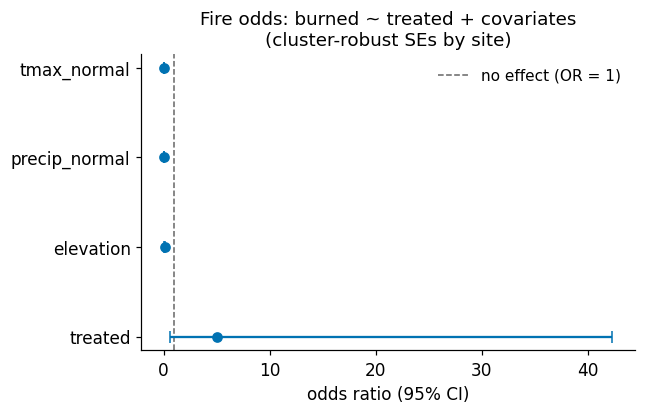

In [26]:
# Headline figure: odds ratio (95% CI) per term, saved to outputs/figures/modeling.
# treated < 1 (CI below the dashed line at OR=1) => restoration lowers fire odds.
tbl = or_table.drop(index="Intercept", errors="ignore")
ypos = np.arange(len(tbl))

fig, ax = plt.subplots(figsize=(6, 0.6 * len(tbl) + 1.5))
ax.errorbar(
    tbl["odds_ratio"],
    ypos,
    xerr=[tbl["odds_ratio"] - tbl["or_ci_low"], tbl["or_ci_high"] - tbl["odds_ratio"]],
    fmt="o",
    capsize=4,
    zorder=3,
)
ax.axvline(1.0, ls="--", color="0.4", lw=1, label="no effect (OR = 1)")
ax.set_yticks(ypos)
ax.set_yticklabels(tbl.index)
ax.set_xlabel("odds ratio (95% CI)")
ax.set_title("Fire odds: burned ~ treated + covariates\n(cluster-robust SEs by site)")
ax.legend()
fig.savefig(FIG_DIR / "odds_ratios.png", bbox_inches="tight")
print("saved", FIG_DIR / "odds_ratios.png")

### Next

- **Dry-year interaction.** Per-year climate is now built (`precip` / `tmax` /
  `tmin` under `processed/climate/annual/`) and `build_frame` joins it per
  `(x, y, year)`, so you can fit `burned ~ treated * precip + elevation +
  histosol_pct` to test whether restoration's effect is larger in dry years.
- Step up to `fit_mixed_logit` (site random intercept) to cross-check the SEs.
- Swap `product=` to a severity layer to re-run the whole thing for severity.